# Too Hard / Soft 분석

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
data1 = pd.read_csv("review-vc_sales_by_collection.csv")
data2 = pd.read_csv("review-vc_sales_exclude_too_hard_too_soft.csv")

In [5]:
cols = ['12in Green Tea MF','10in PPSM Hybrid','12in NEBT']

In [6]:
original_cols = data1[data1['collection'].isin(cols)].copy()
excluded_cols = data2[data2['collection'].isin(cols)].copy()

In [7]:
original_cols['rating_bin'] = original_cols['written_avg_rating'].round(1)
excluded_cols['rating_bin'] = excluded_cols['written_avg_rating'].round(1)

In [8]:
original_cols['sales_amount'].sum()
#excluded_cols['sales_amount'].sum()

163074885.84

In [9]:
#platform_cols['rating_bin'] = platform_cols['written_avg_rating'].round(1)

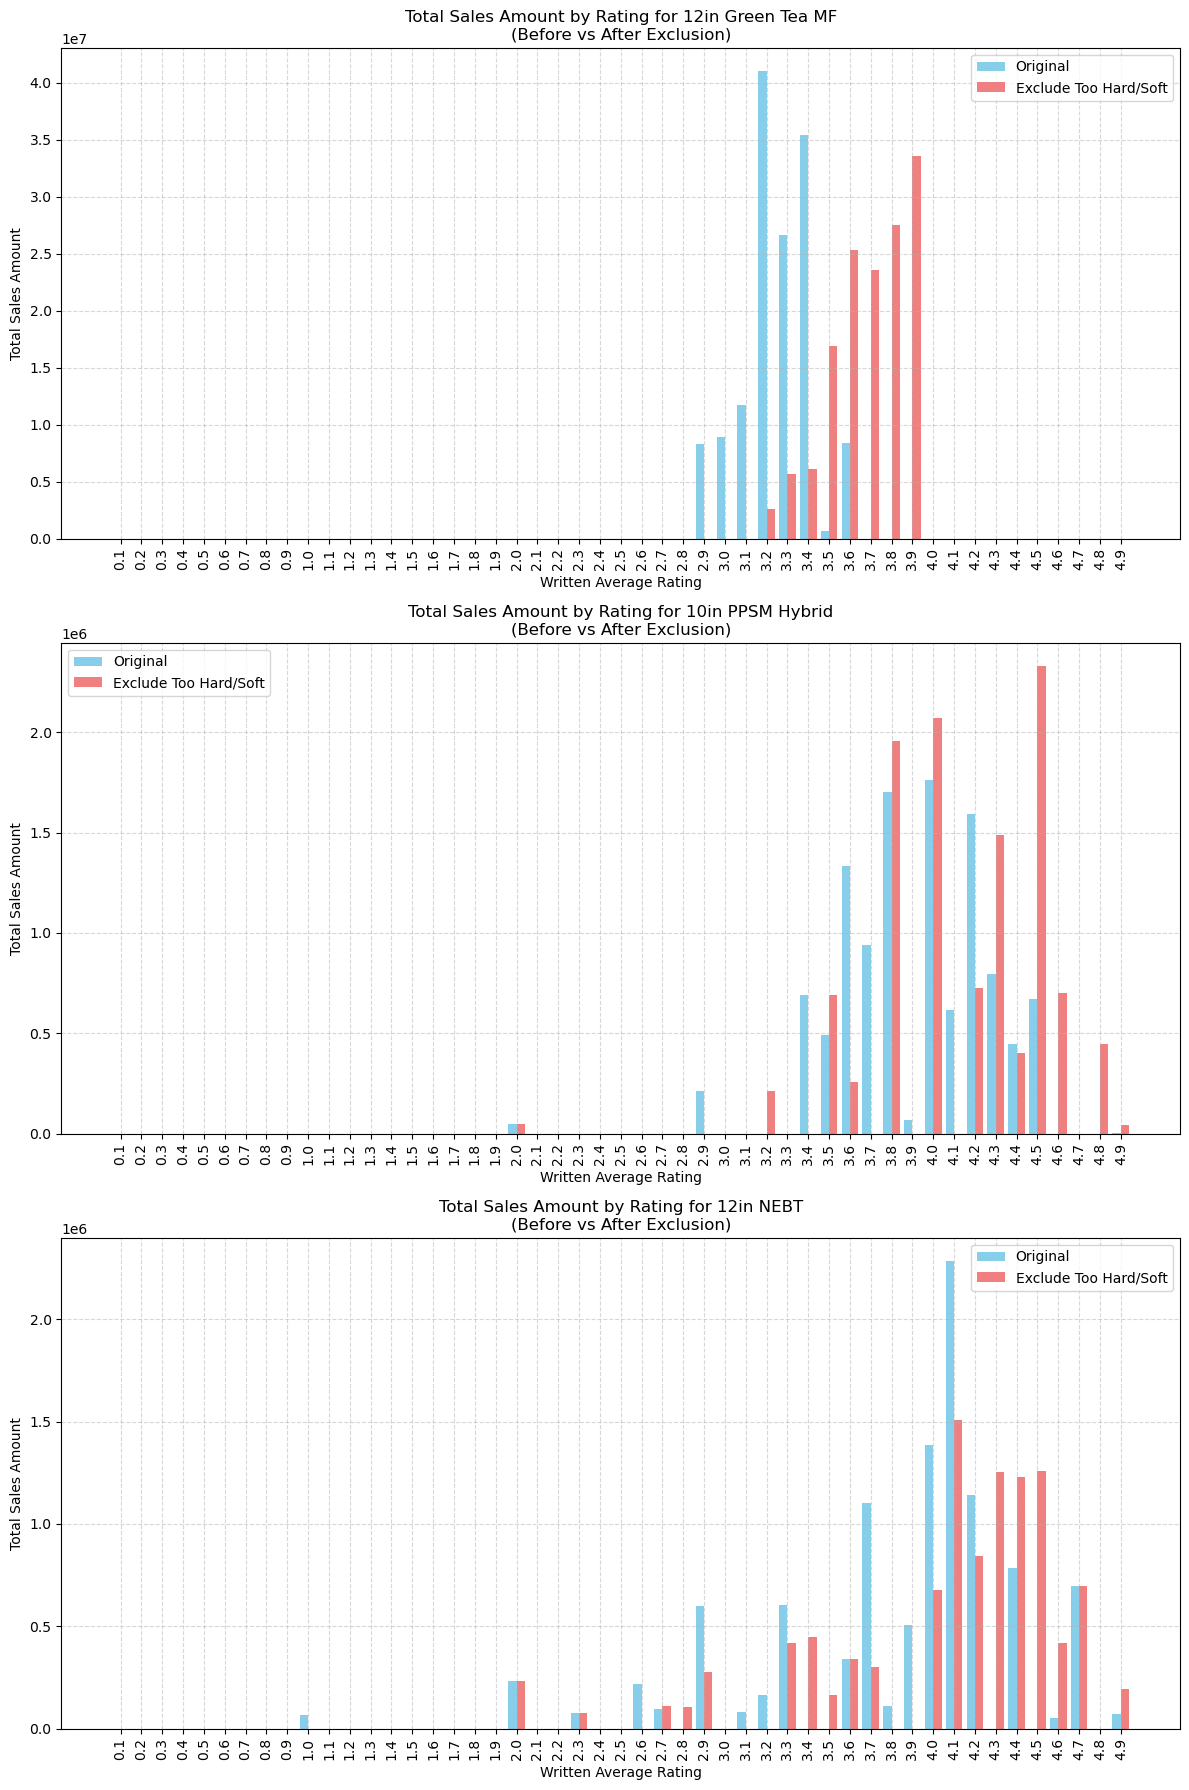

In [10]:
fig, axes = plt.subplots(3,1,figsize=(12,18))
bins = np.arange(0.1,5.1,0.1)

for i, collection in enumerate(cols):
    original_cols_data = original_cols[original_cols['collection']==collection] 
    excluded_cols_data = excluded_cols[excluded_cols['collection']==collection]

    original_hist, _ = np.histogram(original_cols_data['written_avg_rating'], bins=bins, weights=original_cols_data['sales_amount'])
    excluded_hist, _ = np.histogram(excluded_cols_data['written_avg_rating'], bins=bins, weights=excluded_cols_data['sales_amount'])

    bar_width = 0.4
    indices = np.arange(len(bins)-1)

    axes[i].bar(indices, original_hist, bar_width, label='Original', color='skyblue')
    axes[i].bar(indices+bar_width, excluded_hist, bar_width, label='Exclude Too Hard/Soft', color='lightcoral')

    axes[i].set_xlabel('Written Average Rating')
    axes[i].set_ylabel('Total Sales Amount')
    axes[i].set_title(f'Total Sales Amount by Rating for {collection}\n(Before vs After Exclusion)')

    axes[i].set_xticks(indices+bar_width/2)
    axes[i].set_xticklabels([f'{bins[j]:.1f}' for j in range(len(bins)-1)], rotation=90)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()